In [48]:
import json
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [49]:
SIZE = 32 #sizes 16, 32, 64

In [972]:
def add_padding(size, grid):
    padded_grid = [[1] * (size + 2) for _ in range(size + 2)]
    
    for i in range(size):
        for j in range(size):
            padded_grid[i + 1][j + 1] = grid[i][j]
    
    return padded_grid

In [973]:
def save_grid_to_json(grid, filename):
    with open(filename, 'w') as f:
        json.dump(grid, f, indent=2)

In [974]:
def create_empty_grid(size=SIZE):
    grid = [[0] * size for _ in range(size)]

    return grid

In [975]:
def place_agent(size, grid):
    agent_x = random.randint(0, size // 8)
    agent_y = random.randint(size // 4, 3 * size // 4)
     
    while grid[agent_x][agent_y] == 1:  
        agent_x = random.randint(1, size // 8)
        agent_y = random.randint(size // 4, 3 * size // 4)

    return agent_x, agent_y
    

In [976]:
def place_goal(size, grid):
    goal_x = random.randint(7 * size // 8, size - 1)
    goal_y = random.randint(size // 4, 3 * size // 4)
    
    while grid[goal_x][goal_y] == 1:  
        goal_x = random.randint(7 * size // 8, size - 1)
        goal_y = random.randint(size // 4, 3 * size // 4)

    return goal_x, goal_y

In [977]:
def get_free_position_in_top_left(size, grid):
    while True:
        x = random.randint(0, size // 4 - 1)
        y = random.randint(0, size // 4 - 1)
        
        if grid[x][y] == 0:
            return x, y

In [978]:
def get_free_position_in_bottom_right(size, grid):
    while True:
        x = random.randint(size - size // 6, size - 2)
        y = random.randint(size - size // 6, size - 2)
        
        if grid[x][y] == 0:
            return x, y

In [979]:
def create_star_grid(size=SIZE, save_grid=False):
    # Erstellen des leeren Grids
    grid =  create_empty_grid(size)
    
    # Dynamische Parameter für das Muster
    # Unten rechts (l1)
    l1_x = size - size // 3
    l1_y = size - size // 4
    l1_length = size // 4
    l1_thickness = size // 10

    for x in range(l1_x, min(l1_x + l1_length, size)):
        for y in range(l1_y, min(l1_y + l1_thickness, size)):
             grid[x][y] = 1

    for x in range(l1_x, min(l1_x + l1_thickness, size)):
        for y in range(l1_y, min(l1_y + l1_length, size)):
            grid[x][y] = 1

    # Oben links (l2)
    l2_x = size // 10
    l2_y = size // 5
    l2_length = size // 4
    l2_thickness = size // 10

    for x in range(l2_x, min(l2_x + l2_length, size)):
        for y in range(l2_y, min(l2_y + l2_thickness, size)):
            grid[x][y] = 1

    for x in range(l2_x + l2_length - l2_thickness, min(l2_x + l2_length, size)):
        for y in range(l2_y, min(l2_y - l2_length, size), - 1):
            grid[x][y] = 1
    
    grid = add_padding(size,grid)
    
    # Bestimmen der Positionen für Agent und Ziel
    agent_x, agent_y = get_free_position_in_top_left(size, grid)
    goal_x, goal_y = get_free_position_in_bottom_right(size, grid)

    
    # Grid speichern, wenn der Parameter aktiviert ist
    if save_grid:
        save_grid_to_file({
            "name": "detour",
            "agent_x": agent_x,
            "agent_y": agent_y,
            "goal_x": goal_x,
            "goal_y": goal_y,
            "size": size,
            "grid": grid
        })

    # Rückgabe des Grids mit Metadaten
    return {
        "name": "detour",
        "agent_x": agent_x,
        "agent_y": agent_y,
        "goal_x": goal_x,
        "goal_y": goal_y,
        "size": size,
        "grid": grid
    }


In [980]:
def create_simple_grid(size=SIZE, save_grid=False):
    # Erstellen eines leeren Grids
    grid = create_empty_grid(size)
    
    num_rect = min(2, size // 15)  

    rectangles = []
    for _ in range(num_rect):
        max_attempts = 100  # Verhindert Endlosschleifen
        attempts = 0
        while attempts < max_attempts:
            # Dimensionen der Rechtecke proportional zur Größe des Grids
            rect_width = random.randint(size // 10, size // 4)
            rect_height = random.randint(size // 10, size // 4)

            # Positionen der Rechtecke innerhalb des zentralen Bereichs des Grids
            rect_x = random.randint(size // 4, 3 * size // 4 - rect_width - 1)
            rect_y = random.randint(size // 4, 3 * size // 4 - rect_height - 1)

            # Überprüfen, ob das Rechteck keinen anderen Rechtecken zu nahe kommt
            valid_position = True
            for existing_rect in rectangles:
                ex_x, ex_y, ex_width, ex_height = existing_rect

                # Prüfen auf Überschneidung mit einem Puffer von 1 Pixel
                if not (rect_x >= ex_x + ex_width + 1 or  # rechts vom bestehenden Rechteck
                        rect_x + rect_width + 1 <= ex_x or  # links vom bestehenden Rechteck
                        rect_y >= ex_y + ex_height + 1 or  # unterhalb des bestehenden Rechtecks
                        rect_y + rect_height + 1 <= ex_y):  # oberhalb des bestehenden Rechtecks
                    valid_position = False
                    break

            if valid_position:
                rectangles.append((rect_x, rect_y, rect_width, rect_height))

                # Rechteck im Grid markieren
                for x in range(rect_x, rect_x + rect_width):
                    for y in range(rect_y, rect_y + rect_height):
                        grid[x][y] = 1

                break

            attempts += 1

        if attempts == max_attempts:
            print("Hindernis konnte nicht platziert werden")

    agent_x, agent_y = place_agent(size, grid)
    goal_x, goal_y = place_goal(size,grid)

    grid = add_padding(size,grid)

    # Grid speichern, wenn der Parameter aktiviert ist
    if save_grid:
        save_grid_to_file({
            "name": "detour",
            "agent_x": agent_x,
            "agent_y": agent_y,
            "goal_x": goal_x,
            "goal_y": goal_y,
            "size": size,
            "grid": grid
        })

    # Rückgabe des Grids mit Metadaten
    return {
        "name": "detour",
        "agent_x": agent_x,
        "agent_y": agent_y,
        "goal_x": goal_x,
        "goal_y": goal_y,
        "size": size,
        "grid": grid
    }


In [981]:
def create_bottleneck_grid(size=SIZE, save_grid=False):
    grid = create_empty_grid(size)

    # Blockierter Balken
    balken_x = size // 3  # Position des Balkens
    balken_dicke = max(1, size // 2)  # Dicke des Balkens proportional zur Größe

    for y in range(size):
        for x in range(balken_x, balken_x + balken_dicke):
            grid[x][y] = 1

    bottleneck_width_top = max(1, size // 12)  # Enger Bereich oben
    bottleneck_width_bottom = max(1, size // 6)  # Breiterer Bereich unten
    bottleneck_y_center = size // 2  # Zentrale Position des Weges

    # Obere schmale Passage
    for y in range(bottleneck_y_center - bottleneck_width_top // 2, bottleneck_y_center + (bottleneck_width_top + 1) // 2):
        for x in range(balken_x, balken_x + balken_dicke // 2):
            if 0 <= y < size:
                grid[x][y] = 0

    # Untere breitere Passage
    for y in range(bottleneck_y_center - bottleneck_width_bottom // 2, bottleneck_y_center + (bottleneck_width_bottom + 1) // 2):
        for x in range(balken_x + balken_dicke // 2, balken_x + balken_dicke):
            if 0 <= y < size:
                grid[x][y] = 0

    grid = add_padding(size,grid)

    agent_x, agent_y = place_agent(size, grid)
    goal_x, goal_y = place_goal(size, grid)


    # Grid speichern, wenn der Parameter aktiviert ist
    if save_grid:
        save_grid_to_file({
            "name": "detour",
            "agent_x": agent_x,
            "agent_y": agent_y,
            "goal_x": goal_x,
            "goal_y": goal_y,
            "size": size,
            "grid": grid
        })

    # Rückgabe des Grids mit Metadaten
    return {
        "name": "detour",
        "agent_x": agent_x,
        "agent_y": agent_y,
        "goal_x": goal_x,
        "goal_y": goal_y,
        "size": size,
        "grid": grid
    }

In [982]:
def create_trap_grid(size=SIZE, save_grid=False):
    grid = create_empty_grid(size)

    # Definieren der Rechtecksgrenzen dynamisch basierend auf der Größe
    rect_start_x = size // 5
    rect_start_y = size // 5
    rect_end_x = size - size // 5
    rect_end_y = size - size // 5

    # Rechteck zeichnen
    for x in range(rect_start_x, rect_end_x):
        for y in range(rect_start_y, rect_end_y):
            grid[x][y] = 1

    # Dynamisches Loch innerhalb des Rechtecks erstellen (Buchtform)
    hole_width = random.randint((rect_end_y - rect_start_y) // 3, (rect_end_y - rect_start_y) // 2)
    hole_height = random.randint((rect_end_x - rect_start_x) // 4, (rect_end_x - rect_start_x) // 2) 

    # Loch mittig am oberen Rand des Rechtecks platzieren
    hole_start_x = rect_start_x
    hole_start_y = rect_start_y  + (rect_end_y - rect_start_y - hole_width) // 2  # Loch beginnt oben am Rechteck

    for x in range(hole_start_x, hole_start_x + hole_width):
        for y in range(hole_start_y, hole_start_y + hole_height):
            if rect_start_x <= x < rect_end_x and rect_start_y <= y < rect_end_y:
                if random.random() > 0.1: 
                    grid[x][y] = 0  

    grid = add_padding(size,grid)

    # Position des Agenten (oben im Grid, außerhalb des Rechtecks)
    agent_x, agent_y = place_agent(size, grid)
    
    # Position des Ziels (unten im Grid, außerhalb des Rechtecks)
    goal_x, goal_y = place_goal(size, grid)
    

    # Grid speichern, wenn der Parameter aktiviert ist
    if save_grid:
        save_grid_to_file({
            "name": "detour",
            "agent_x": agent_x,
            "agent_y": agent_y,
            "goal_x": goal_x,
            "goal_y": goal_y,
            "size": size,
            "grid": grid
        })

    # Rückgabe des Grids mit Metadaten
    return {
        "name": "detour",
        "agent_x": agent_x,
        "agent_y": agent_y,
        "goal_x": goal_x,
        "goal_y": goal_y,
        "size": size,
        "grid": grid
    }

In [1004]:
def create_doubletrap_grid(size=SIZE, save_grid=False):
    grid = create_empty_grid(size)

    # Dynamische Rechtecksgrenzen basierend auf der Größe
    rect_start_x = size // 5
    rect_start_y = size // 5
    rect_end_x = size - size // 5
    rect_end_y = size - size // 5

    # Rechteck zeichnen
    for x in range(rect_start_x, rect_end_x):
        for y in range(rect_start_y, rect_end_y):
            grid[x][y] = 1

    # Erste Falle dynamisch erstellen
    hole_width = random.randint((rect_end_y - rect_start_y) // 4, (rect_end_y - rect_start_y) // 2)
    hole_height = random.randint((rect_end_x - rect_start_x) // 4, (rect_end_x - rect_start_x) // 2) 

    # Loch mittig am oberen Rand des Rechtecks platzieren
    hole_start_x = rect_start_x
    hole_start_y = rect_start_y  + (rect_end_y - rect_start_y - hole_width) // 2  # Loch beginnt oben am Rechteck

    for x in range(hole_start_x, hole_start_x + hole_width):
        for y in range(hole_start_y, hole_start_y + hole_height):
            if rect_start_x <= x < rect_end_x and rect_start_y <= y < rect_end_y:
                grid[x][y] = 0

    # Zweite Falle (gespiegelt) dynamisch erstellen
    hole_start_x_mirror = rect_end_x - (hole_start_x + hole_width - rect_start_x)
    hole_start_y_mirror = rect_end_y - (hole_start_y + hole_height - rect_start_y)
    hole_width_mirror = hole_width
    hole_height_mirror = hole_height

    for x in range(hole_start_x_mirror, hole_start_x_mirror + hole_width_mirror):
        for y in range(hole_start_y_mirror, hole_start_y_mirror + hole_height_mirror):
            if rect_start_x <= x < rect_end_x and rect_start_y <= y < rect_end_y:
                grid[x][y] = 0

    grid = add_padding(size,grid)

    # Position des Agenten (oben im Grid, außerhalb des Rechtecks)
    agent_x, agent_y = place_agent(size, grid)

    # Position des Ziels (unten im Grid, außerhalb des Rechtecks)
    goal_x, goal_y = place_goal(size, grid)

    
    # Grid speichern, wenn der Parameter aktiviert ist
    if save_grid:
        save_grid_to_file({
            "name": "detour",
            "agent_x": agent_x,
            "agent_y": agent_y,
            "goal_x": goal_x,
            "goal_y": goal_y,
            "size": size,
            "grid": grid
        })

    # Rückgabe des Grids mit Metadaten
    return {
        "name": "detour",
        "agent_x": agent_x,
        "agent_y": agent_y,
        "goal_x": goal_x,
        "goal_y": goal_y,
        "size": size,
        "grid": grid
    }

In [984]:
def create_detour_grid(size=SIZE, save_grid=False): ## funzt noch ned auf 16 byye
    grid = create_empty_grid(size)

    # Definieren der Rechtecksgrenzen für die Hindernisse oben und unten
    rect_start_x = size // 5
    rect_start_y = 0
    rect_end_x = size - size // 5
    rect_end_y = size - size // 5

    # Rechtecke zeichnen
    for x in range(rect_start_x, rect_end_x):
        for y in range(rect_start_y, rect_end_y):
            grid[x][y] = 1

    # Vertikales Zickzack-Muster innerhalb des Rechtecks
    zickzack_depth = (rect_end_y - rect_start_y) // 4  # Tiefe der Zickzack-Spitzen
    zickzack_width = (rect_end_x - rect_start_x) // 7 # Breite der Zickzack-Abschnitte

    for i in range(10):
        center_y = rect_start_y + (rect_end_y - rect_start_y) // 3
        if i % 2 == 0:  # Zick (nach links in das Hindernis)
            for x in range(rect_start_x + i * zickzack_width, rect_start_x + (i + 1) * zickzack_width):
                y_spike = center_y - zickzack_depth // 2
                grid[x][y_spike] = 0  # Spitze
                grid[x + 1][y_spike] = 0
            for y in range(center_y - zickzack_depth // 2, center_y + zickzack_depth // 2):
                grid[rect_start_x + i * zickzack_width][y] = 0
        else:  # Zack (nach rechts in das Hindernis)
            for x in range(rect_start_x + i * zickzack_width, rect_start_x + (i + 1) * zickzack_width):
                y_spike = center_y + zickzack_depth // 2
                grid[x][y_spike] = 0  # Spitze
                grid[x + 1][y_spike - 1] = 0
            for y in range(center_y - zickzack_depth // 2, center_y + zickzack_depth // 2):
                grid[rect_start_x + i * zickzack_width][y] = 0

    grid = add_padding(size,grid)

    # Position des Agenten (oben links im Zickzack-Bereich)
    agent_x, agent_y = place_agent(size, grid)
    agent_y = agent_y // 4

    # Position des Ziels (unten rechts im Zickzack-Bereich)
    goal_x, goal_y = place_goal(size, grid)
    goal_y = goal_y // 4


    # Grid speichern, wenn der Parameter aktiviert ist
    if save_grid:
        save_grid_to_file({
            "name": "detour",
            "agent_x": agent_x,
            "agent_y": agent_y,
            "goal_x": goal_x,
            "goal_y": goal_y,
            "size": size,
            "grid": grid
        })

    # Rückgabe des Grids mit Metadaten
    return {
        "name": "detour",
        "agent_x": agent_x,
        "agent_y": agent_y,
        "goal_x": goal_x,
        "goal_y": goal_y,
        "size": size,
        "grid": grid
    }


In [985]:
def get_grid_img(grid, agent, goal, path=False):
    data = grid
    if path:
        for p in path:
            data[p[0]][p[1]] = 4

    data[agent[0]][agent[1]] = 2
    data[goal[0]][goal[1]] = 3

    return data

def plot_grid(data, row_labels, col_labels, ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()

    # create custom colors
    # ToDo: schönere Farben aussuchen
    colors = ["#ffffcc", "#a1dab4", "#41b6c4", "#2c7fb8", "#253494"]
    custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors)

    # Plot the heatmap
    im = ax.imshow(data, cmap=custom_cmap, **kwargs)

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(np.arange(len(data[0])), labels=col_labels)
    ax.set_yticks(np.arange(len(data[0])), labels=row_labels)

    # Let the horizontal axes labeling appear on top.
    ax.tick_params(top=True, bottom=False,
                   labeltop=True, labelbottom=False)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=-30, ha="right",
             rotation_mode="anchor")

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)

    ax.set_xticks(np.arange(len(data[0]) + 1) - .5, minor=True)
    ax.set_yticks(np.arange(len(data[0]) + 1) - .5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im


In [1041]:
#grid_data = create_star_grid(32) 
#grid_data = create_simple_grid(32)
#grid_data = create_bottleneck_grid(32)
#grid_data = create_trap_grid(32)
#grid_data = create_doubletrap_grid(32)
#grid_data = create_detour_grid(32)
                               
#visualize_grid_with_agent_and_goal(grid_data["grid"], grid_data["agent_x"], grid_data["agent_y"], grid_data["goal_x"], grid_data["goal_y"])
data = get_grid_img(grid_data["grid"], (grid_data["agent_x"], grid_data["agent_y"]), (grid_data["goal_x"], grid_data["goal_y"]))

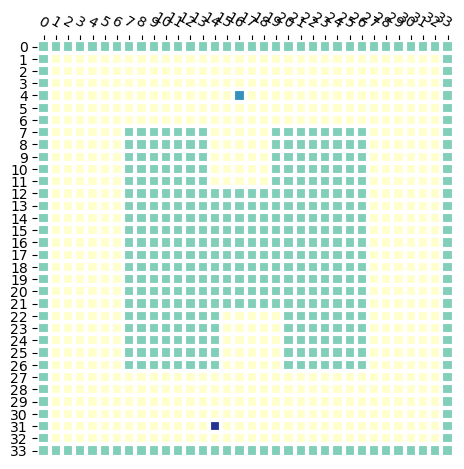

In [1042]:
fig, ax = plt.subplots()
#
im = plot_grid(data, range(len(data[0])), range(len(data[0])), ax=ax)
#
fig.tight_layout()
plt.show()